### 03. Exploring the Tempel et al. 2014 filament catalog

This notebook studies the properties of Tempel+2014 survey region, which overlaps with the eROSITA-DE all sky survey.


**Author**: Soumya Shreeram <br/>
**Date created**: 7th April 2022 <br/>
**Last edited**: tbu <br/>

In [1]:
# astropy modules
import astropy.units as u
import astropy.io.fits as fits

from astropy.table import Table, Column, join
from astropy.coordinates import SkyCoord
from astropy.cosmology import FlatLambdaCDM, z_at_value

import numpy as np

# system imports
import os
import sys
import importlib as ib
import glob
import gzip

# plotting imports
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns

from scipy.stats import norm
from scipy import interpolate
import pandas as pd

In [2]:
matplotlib.rcParams['agg.path.chunksize'] = 100000
%matplotlib inline
font = {'family' : 'serif',
        'weight' : 'medium',
        'size'   : 16}
matplotlib.rc('font', **font)

bright_colors = sns.color_palette("bright")

The directory where the methods/classes/instances used in this notebook are stored.

In [152]:
import filaments as fo

In [153]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [124]:
base_dir = "/data53s/shreeram/Filament_stacking"
code_dir = f"{base_dir}/code"
image_dir = f"{base_dir}/images"
data_dir = f"{base_dir}/data"

In [7]:
this_fil_tempel14 = fo.Filaments(filament_catalogue_name='Tempel_2014_SDSS')
plot_obj_tempel14 = fo.DoPlotFilaments(this_fil_tempel14)

INFO:DoPlotFilaments: Plotting Tempel_2014_SDSS on the all sky projection.
INFO:Filaments: Files in the filament catalogue: 
 ['/data53s/shreeram/Filament_stacking/data/Filament_catalogues/Tempel_2014_SDSS/fil_properties.txt', '/data53s/shreeram/Filament_stacking/data/Filament_catalogues/Tempel_2014_SDSS/fil_point_properties.txt']


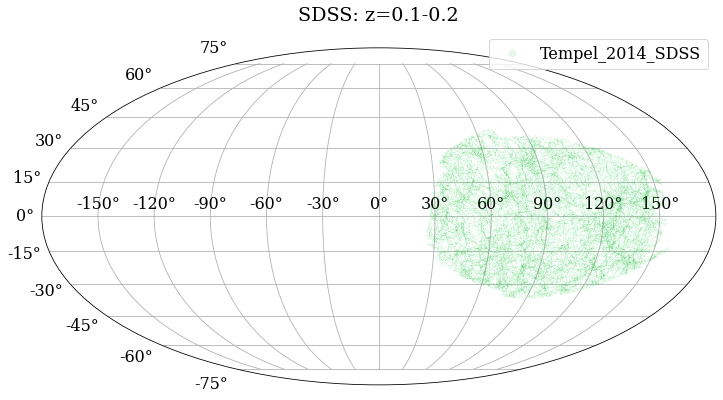

In [9]:
plot_obj_tempel14.plot_filaments_on_sky(color=bright_colors[2], ms=0.1, alpha=0.5)

Reduce the catalog to a new one which overlaps with the eRASS sky

INFO:DoPlotFilaments: Plotting Tempel_2014_SDSS on the all sky projection.
INFO:Filaments: Files in the filament catalogue: 
 ['/data53s/shreeram/Filament_stacking/data/Filament_catalogues/Tempel_2014_SDSS/fil_properties.txt', '/data53s/shreeram/Filament_stacking/data/Filament_catalogues/Tempel_2014_SDSS/fil_point_properties.txt']
INFO:Filaments: Files in the filament catalogue: 
 ['/data53s/shreeram/Filament_stacking/data/Filament_catalogues/Tempel_2014_SDSS/fil_properties.txt', '/data53s/shreeram/Filament_stacking/data/Filament_catalogues/Tempel_2014_SDSS/fil_point_properties.txt']
INFO:DoPlotFilaments: We have overlapping filaments with the eRASS sky!
INFO:DoPlotFilaments: Number of filaments found is 13237
INFO:DoPlotFilaments: Number of filaments longer than 5 Mpc: 8389


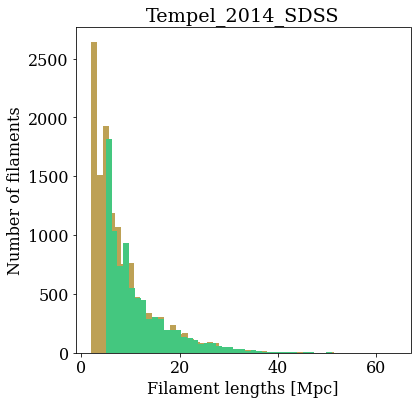

In [16]:
fig, ax = plt.subplots(1, 1, figsize=(6, 6))

# eRASS sky tile edges 
ax = plot_obj_tempel14.plot_filament_lengths_Tempel14(ax)
fig.patch.set_facecolor('white')

In [25]:
filament_file_object = fo.Filaments2Files(this_filament_obj = this_fil_tempel14)

In [107]:
ra_dec_fil_points = filament_file_object.get_filament_lengths()

INFO:Filaments: Files in the filament catalogue: 
 ['/data53s/shreeram/Filament_stacking/data/Filament_catalogues/Tempel_2014_SDSS/fil_properties.txt', '/data53s/shreeram/Filament_stacking/data/Filament_catalogues/Tempel_2014_SDSS/fil_point_properties.txt']
INFO:Filaments2Files: 13237 filaments with lengths 8+/-2 Mpc


[ True  True  True ...  True  True  True]


INFO:Filaments2Files: Size of filament points array (13237, 2)


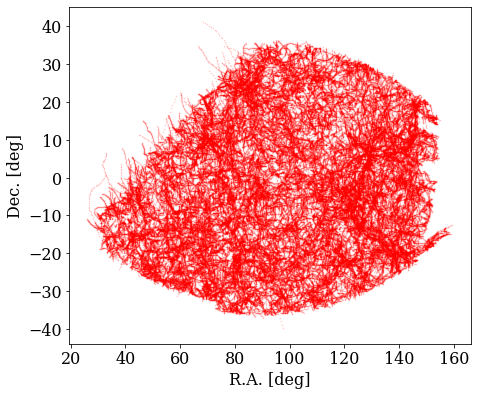

In [135]:
fig, ax = plt.subplots(1, 1, figsize=(7.2,6.2))

# plot on all sky-map
for pos_fil in ra_dec_fil_points[0]:
    ax.plot(pos_fil[0].to(u.deg), pos_fil[1].to(u.deg), '.', c='r', alpha=0.2, ms=1)

fo.set_labels(ax, 'R.A. [deg]', 'Dec. [deg]')
fig.patch.set_facecolor('white')
fig.savefig(f'{image_dir}/8pm2Mpcfil.png', format='png')

AttributeError: module 'filaments' has no attribute 'set_as_white'

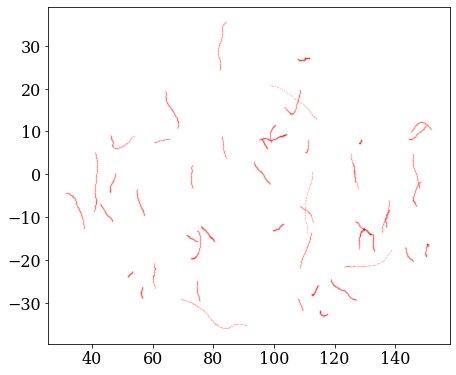

In [157]:
plot_no_fils = 50
fig, ax = plt.subplots(1, 1, figsize=(7.2,6.2))

# plot on all sky-map
for pos_fil in ra_dec_fil_points[0][:plot_no_fils]:
    ax.plot(pos_fil[0].to(u.deg), pos_fil[1].to(u.deg), '.', c='r', alpha=0.2, ms=1)

ax = fo.set_as_white(ax)
fo.set_labels(ax, 'R.A. [deg]', 'Dec. [deg]', title=f'{plot_no_fils} filaments', legend=False)
fig.patch.set_facecolor('white')


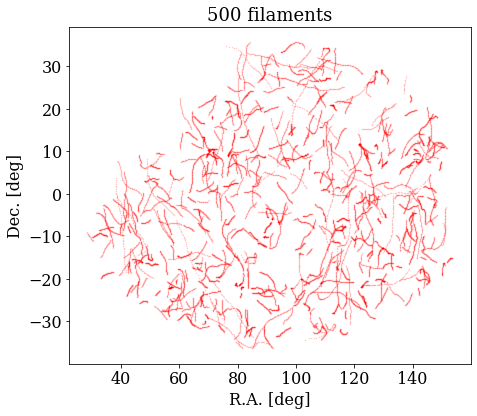

In [133]:
plot_no_fils = 500
fig, ax = plt.subplots(1, 1, figsize=(7.2,6.2))

# plot on all sky-map
for pos_fil in ra_dec_fil_points[0][:plot_no_fils]:
    ax.plot(pos_fil[0].to(u.deg), pos_fil[1].to(u.deg), '.', c='r', alpha=0.2, ms=1)

fo.set_labels(ax, 'R.A. [deg]', 'Dec. [deg]', title=f'{plot_no_fils} filaments')
fig.patch.set_facecolor('white')

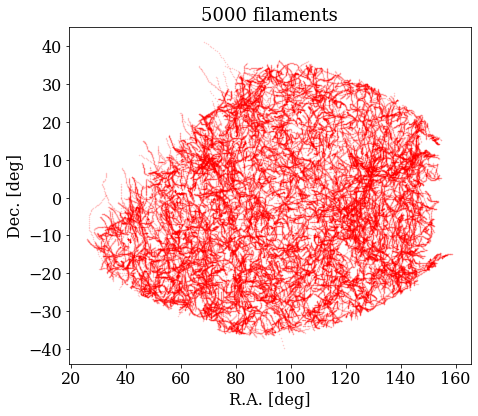

In [130]:
plot_no_fils = 5000
fig, ax = plt.subplots(1, 1, figsize=(7.2,6.2))

# plot on all sky-map
for pos_fil in ra_dec_fil_points[0][:plot_no_fils]:
    ax.plot(pos_fil[0].to(u.deg), pos_fil[1].to(u.deg), '.', c='r', alpha=0.2, ms=1)

fo.set_labels(ax, 'R.A. [deg]', 'Dec. [deg]', title=f'{plot_no_fils} filaments')
fig.patch.set_facecolor('white')

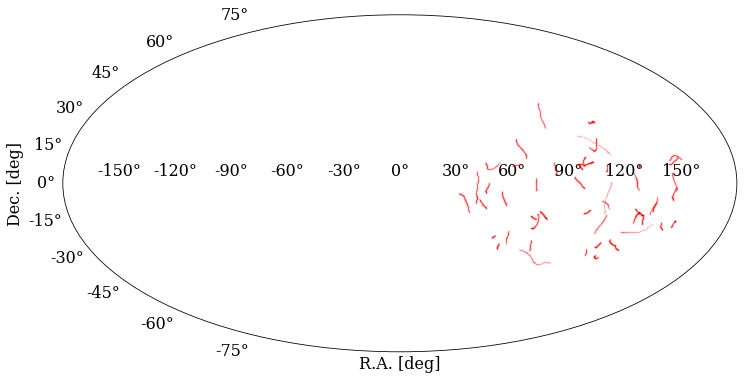

In [132]:
fig = plt.figure(figsize=(14,6.2))
ax = plt.subplot(111, projection="mollweide")

# plot on all sky-map
for pos_fil in ra_dec_fil_points[0][:50]:
    ra, dec = fo.aitoffProjection(pos_fil[0].to(u.deg), pos_fil[1].to(u.deg))
    ax.plot(ra, dec, '.', c='r', alpha=0.2, ms=1)

fo.set_labels(ax, 'R.A. [deg]', 'Dec. [deg]', legend=False)
fig.patch.set_facecolor('white')
fig.savefig(f'{image_dir}/8pm2Mpcfil_mollweide.png', format='png')

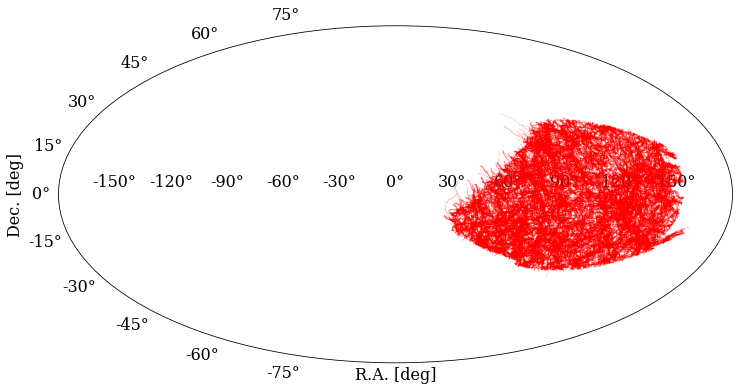

In [137]:
fig = plt.figure(figsize=(14,6.2))
ax = plt.subplot(111, projection="mollweide")

# plot on all sky-map
for pos_fil in ra_dec_fil_points[0]:
    ra, dec = fo.aitoffProjection(pos_fil[0].to(u.deg), pos_fil[1].to(u.deg))
    ax.plot(ra, dec, '.', c='r', alpha=0.2, ms=0.7)

fo.set_labels(ax, 'R.A. [deg]', 'Dec. [deg]', legend=False)
fig.patch.set_facecolor('white')
fig.savefig(f'{image_dir}/8pm2Mpcfil_mollweide.png', format='png')

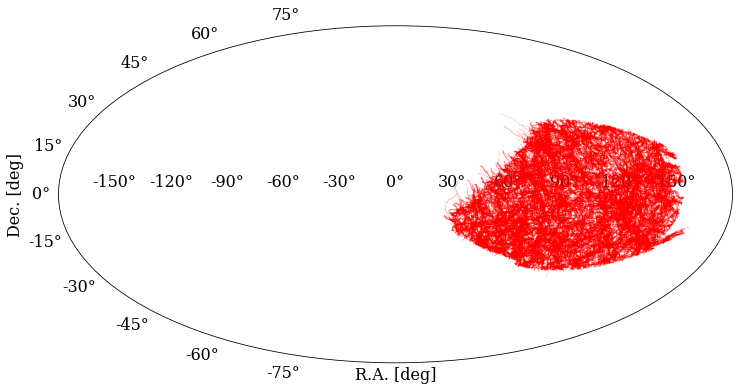

In [139]:
fig = plt.figure(figsize=(14,6.2))
ax = plt.subplot(111, projection="aitoff")

# plot on all sky-map
for pos_fil in ra_dec_fil_points[0]:
    ra, dec = fo.aitoffProjection(pos_fil[0].to(u.deg), pos_fil[1].to(u.deg))
    ax.plot(ra, dec, '.', c='r', alpha=0.2, ms=0.7)

ax.grid()
fo.set_labels(ax, 'R.A. [deg]', 'Dec. [deg]', legend=False)
fig.patch.set_facecolor('white')
fig.savefig(f'{image_dir}/8pm2Mpcfil_aitoff.png', format='png')